# Machine Learning
Employee Salary Prediction Dataset

This notebook follows the same learning pattern as the original notebook, but the real-world dataset is employee salary data. The goal is to understand data handling, EDA, preprocessing, encoding, feature engineering, and scaling before model training.

**Dataset:** Employee Salary Prediction Dataset

**Kaggle link:** https://www.kaggle.com/datasets/gmudit/employer-data

**Problem type:** Supervised Machine Learning → **Regression**

**Target:** `Salary` — annual employee salary.

**Important:** Focus on understanding and preparing the data. We do not train the final prediction model yet.


## 0. Kaggle environment setup

Kaggle attaches the dataset directly to the notebook. Use **Add Input** and attach the Employee Salary Prediction Dataset. The CSV will normally appear somewhere under `/kaggle/input/`.

We use `os.walk()` so the notebook can find the CSV without hardcoding the Kaggle folder name.


In [5]:
import os

dataset_paths = []
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        full_path = os.path.join(dirname, filename)
        print(full_path)
        if filename.lower().endswith('.csv'):
            dataset_paths.append(full_path)

assert dataset_paths, 'No CSV found. Click Add Input and attach the Employee Salary Prediction Dataset.'
print('CSV files found:', len(dataset_paths))


/kaggle/input/datasets/gmudit/employer-data/Employers_data.csv
CSV files found: 1


## 1. Environment & core libraries

| Library | Purpose in this project |
|---|---|
| **NumPy** | Numerical arrays and mathematical operations |
| **Pandas** | Load, clean, filter, group and analyze the employee table |
| **Matplotlib** | Basic charts such as histograms, scatter plots and bar charts |
| **Seaborn** | Statistical visualizations such as box plots and heatmaps |
| **Scikit-learn** | Encoding and scaling now; model training will come later |

The important change from the previous notebook is that every example below uses **employee/salary concepts**, not house-rent concepts.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

sns.set_style('whitegrid')
print('NumPy version:', np.__version__)
print('Pandas version:', pd.__version__)


NumPy version: 2.0.2
Pandas version: 2.3.3


## 2. NumPy fundamentals — arrays, indexing, reshaping, broadcasting and aggregations

Before working with the real employee table, practice the NumPy operations that later appear inside ML preprocessing.


In [7]:
# Example employee salary-related numerical values: annual salaries
salaries = np.array([35000, 45000, 55000, 70000, 85000, 100000])

print('Salary array:', salaries)
print('First salary:', salaries[0])
print('Last salary:', salaries[-1])
print('First three salaries:', salaries[0:3])
print('Mean salary:', salaries.mean())
print('Standard deviation:', salaries.std())
print('Total:', salaries.sum())
print('Index of highest salary:', salaries.argmax())


Salary array: [ 35000  45000  55000  70000  85000 100000]
First salary: 35000
Last salary: 100000
First three salaries: [35000 45000 55000]
Mean salary: 65000.0
Standard deviation: 22546.248764114473
Total: 390000
Index of highest salary: 5


In [8]:
# Reshape six salary values into a 2 × 3 matrix
salary_matrix = salaries.reshape(2, 3)

print('2 x 3 salary matrix:\n', salary_matrix)

# Broadcasting: add ₹5,000 to every value at once
print('After adding ₹5,000:\n', salary_matrix + 5000)

print('Column-wise sum:', salary_matrix.sum(axis=0))
print('Row-wise sum:', salary_matrix.sum(axis=1))


2 x 3 salary matrix:
 [[ 35000  45000  55000]
 [ 70000  85000 100000]]
After adding ₹5,000:
 [[ 40000  50000  60000]
 [ 75000  90000 105000]]
Column-wise sum: [105000 130000 155000]
Row-wise sum: [135000 255000]


## 3. Loading the real Employee Salary dataset — Pandas Series & DataFrame

A **Series** is one labeled column. A **DataFrame** is the complete table.

The important columns in this dataset include employee information such as `Employee_ID`, `Age`, `Gender`, `Education_Level`, `Department`, `Job_Title`, `Location`, `Experience_Years`, and `Salary`.


In [9]:
# Use the CSV discovered by os.walk().
# Prefer the CSV that contains a Salary column if several CSV files are attached.
salary_paths = []
for path in dataset_paths:
    try:
        sample = pd.read_csv(path, nrows=5)
        if 'Salary' in sample.columns:
            salary_paths.append(path)
    except Exception:
        pass

assert salary_paths, 'No employee salary CSV with a Salary column was found.'
df = pd.read_csv(salary_paths[0])

# Remove accidental CSV index columns if present.
unnamed_cols = [c for c in df.columns if c.lower().startswith('unnamed')]
if unnamed_cols:
    df = df.drop(columns=unnamed_cols)

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())


Shape: (10000, 10)
Columns: ['Employee_ID', 'Name', 'Age', 'Gender', 'Department', 'Job_Title', 'Experience_Years', 'Education_Level', 'Location', 'Salary']


In [10]:
# First five employee salary records
df.head()


,Employee_ID,Name,Age,Gender,Department,Job_Title,Experience_Years,Education_Level,Location,Salary
0,1,Merle Ingram,24,Female,Engineering,Engineer,1,Master,Austin,90000
1,2,John Mayes,56,Male,Sales,Executive,33,Master,Seattle,195000
2,3,Carlos Wille,21,Male,Engineering,Intern,1,Bachelor,New York,35000
3,4,Michael Bryant,30,Male,Finance,Analyst,9,Bachelor,New York,75000
4,5,Paula Douglas,25,Female,HR,Analyst,2,Master,Seattle,70000


In [11]:
# A single column is a pandas Series.
salary_series = df['Salary']
print(type(salary_series))
salary_series.head()


<class 'pandas.core.series.Series'>


0     90000
1    195000
2     35000
3     75000
4     70000
Name: Salary, dtype: int64

## 4. Structured data, features and target

This is **structured tabular data** because every employee is represented by rows and columns.

### Target
`Salary` is the **target** because our future model will predict annual employee salary.

### Features
Examples of features are `Age`, `Experience_Years`, `Education_Level`, `Department`, `Job_Title`, `Location`, and `Gender`.

Because `Salary` is a continuous numerical value, this is a **regression problem**, not a classification problem.


In [12]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Employee_ID       10000 non-null  int64 
 1   Name              10000 non-null  object
 2   Age               10000 non-null  int64 
 3   Gender            10000 non-null  object
 4   Department        10000 non-null  object
 5   Job_Title         10000 non-null  object
 6   Experience_Years  10000 non-null  int64 
 7   Education_Level   10000 non-null  object
 8   Location          10000 non-null  object
 9   Salary            10000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 781.4+ KB


In [13]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Employee_ID,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
Name,10000,9868,James Smith,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,35.4559,10.000213,21.0,27.0,34.0,43.0,60.0
Gender,10000,2,Male,5108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department,10000,6,Product,1724,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job_Title,10000,5,Manager,3325,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Experience_Years,10000.0,NaN,NaN,NaN,12.3709,9.148951,0.0,5.0,10.0,19.0,37.0
Education_Level,10000,3,Master,4930,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,10000,5,Austin,2034,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Salary,10000.0,NaN,NaN,NaN,115381.5,46066.139047,25000.0,70000.0,120000.0,150000.0,215000.0


## 5. Pandas — loc/iloc, filtering, groupby and merge/join

We now apply the same Pandas concepts to employee salary data.
- `loc` selects rows/columns by labels.
- `iloc` selects rows/columns by integer position.
- Boolean filtering selects employees satisfying a condition.
- `groupby` summarizes salary by department.
- `merge` joins related employee summaries.


In [14]:
# loc: first three rows and useful employee columns
cols = [c for c in ['Department', 'Age', 'Experience_Years', 'Salary'] if c in df.columns]
df.loc[df.index[:3], cols]


,Department,Age,Experience_Years,Salary
0,Engineering,24,1,90000
1,Sales,56,33,195000
2,Engineering,21,1,35000


In [15]:
# iloc: first three rows and first four columns
df.iloc[0:3, 0:4]


,Employee_ID,Name,Age,Gender
0,1,Merle Ingram,24,Female
1,2,John Mayes,56,Male
2,3,Carlos Wille,21,Male


In [16]:
# Filtering: employees with salary above the dataset median
median_salary = df['Salary'].median()
high_salary_employees = df[df['Salary'] > median_salary]
print('Median salary:', median_salary)
high_salary_employees.head()


Median salary: 120000.0


,Employee_ID,Name,Age,Gender,Department,Job_Title,Experience_Years,Education_Level,Location,Salary
1,2,John Mayes,56,Male,Sales,Executive,33,Master,Seattle,195000
5,6,Michael Irving,35,Male,Finance,Manager,8,PhD,New York,125000
7,8,Glenda Leal,47,Female,Marketing,Manager,24,Master,San Francisco,145000
8,9,Walter Williams,43,Male,Marketing,Manager,16,PhD,San Francisco,135000
12,13,Lionel Elsea,48,Male,Product,Manager,21,PhD,Seattle,150000


In [17]:
# Groupby: average salary by department
avg_salary_by_department = df.groupby('Department')['Salary'].mean().sort_values(ascending=False)
avg_salary_by_department


Department
Finance        130376.175549
Sales          127309.766327
HR             126400.602410
Product        116676.334107
Marketing      101734.571600
Engineering     90680.332739
Name: Salary, dtype: float64

In [18]:
# Example merge: a small department-level summary table can be joined back to employees.
department_summary = df.groupby('Department', as_index=False)['Salary'].mean()
department_summary = department_summary.rename(columns={'Salary': 'Average_Department_Salary'})

merged_df = df.merge(department_summary, on='Department', how='left')
merged_df.head()


,Employee_ID,Name,Age,Gender,Department,Job_Title,Experience_Years,Education_Level,Location,Salary,Average_Department_Salary
0,1,Merle Ingram,24,Female,Engineering,Engineer,1,Master,Austin,90000,90680.332739
1,2,John Mayes,56,Male,Sales,Executive,33,Master,Seattle,195000,127309.766327
2,3,Carlos Wille,21,Male,Engineering,Intern,1,Bachelor,New York,35000,90680.332739
3,4,Michael Bryant,30,Male,Finance,Analyst,9,Bachelor,New York,75000,130376.175549
4,5,Paula Douglas,25,Female,HR,Analyst,2,Master,Seattle,70000,126400.602410


## 6. Visualization — understanding salary before modeling

Good visualizations answer questions such as:
- What does the salary distribution look like?
- How does experience relate to salary?
- Which departments have higher average salaries?
- Are there potential salary outliers?
- How are numerical variables correlated?


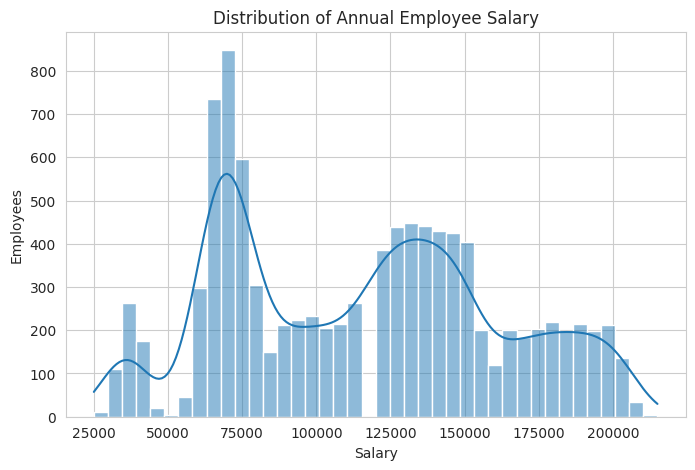

In [19]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Salary'].dropna(), bins=40, kde=True)
plt.title('Distribution of Annual Employee Salary')
plt.xlabel('Salary')
plt.ylabel('Employees')
plt.show()


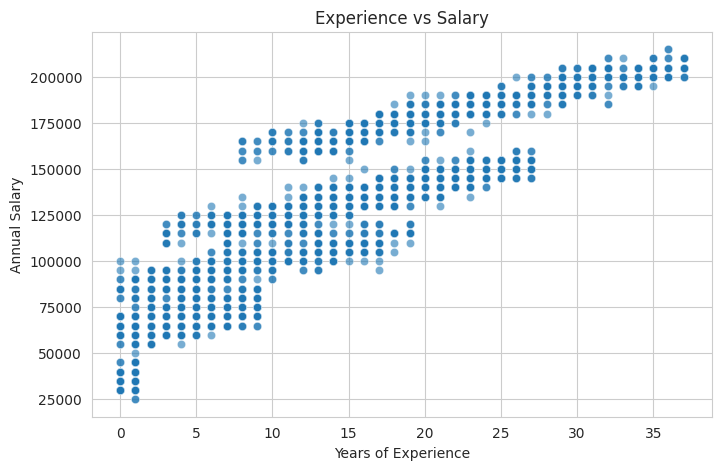

In [20]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df.sample(min(3000, len(df)), random_state=42),
    x='Experience_Years',
    y='Salary',
    alpha=0.6
)
plt.title('Experience vs Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Annual Salary')
plt.show()


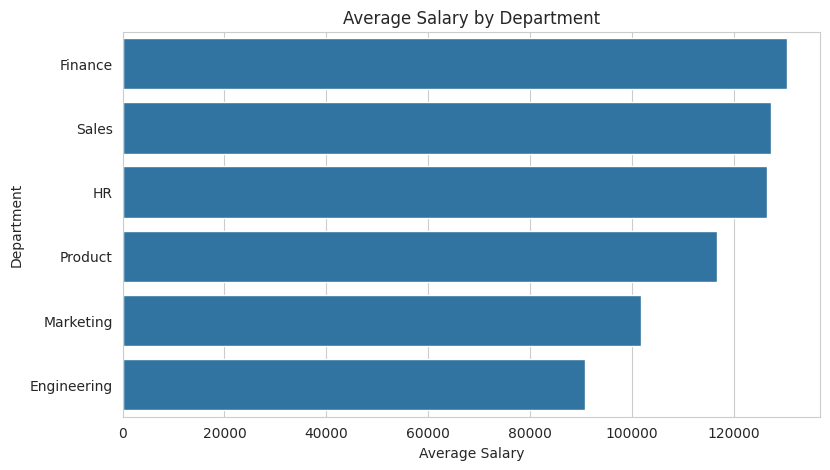

In [21]:
top_department_salary = df.groupby('Department')['Salary'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(9, 5))
sns.barplot(x=top_department_salary.values, y=top_department_salary.index)
plt.title('Average Salary by Department')
plt.xlabel('Average Salary')
plt.ylabel('Department')
plt.show()


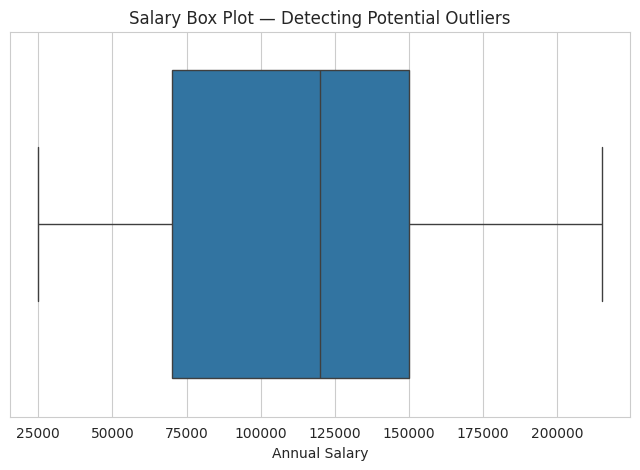

In [22]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Salary'].dropna())
plt.title('Salary Box Plot — Detecting Potential Outliers')
plt.xlabel('Annual Salary')
plt.show()


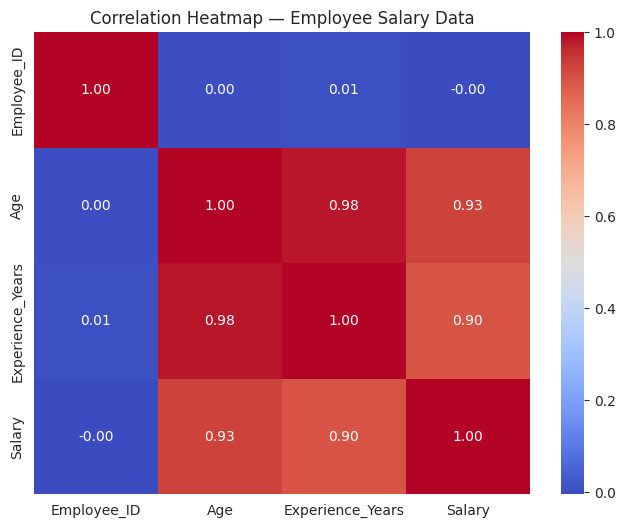

In [23]:
numeric_cols = df.select_dtypes(include=np.number)
corr = numeric_cols.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap — Employee Salary Data')
plt.show()


## 7. EDA conclusions

From the charts, focus on relationships that are meaningful for salary prediction. `Experience_Years`, `Age`, education level, department and job role can provide useful information for predicting `Salary`.

The strongest numerical relationship can be explored using the correlation matrix and the experience-vs-salary scatter plot.


In [24]:
print('Rows:', len(df))
print('Columns:', len(df.columns))
print('Missing values:', int(df.isnull().sum().sum()))
print('Duplicate rows:', int(df.duplicated().sum()))
print('Target column:', 'Salary')
print('Unique salary values:', df['Salary'].nunique())


Rows: 10000
Columns: 10
Missing values: 0
Duplicate rows: 0
Target column: Salary
Unique salary values: 39


## 8. Data preprocessing — missing values, duplicates and outliers

Cleaning must be done carefully. We should not blindly delete unusual salary values because high salaries can be genuine.

We will:
- inspect missing values,
- remove duplicate records,
- ensure the target `Salary` is available,
- inspect salary outliers using the IQR rule.


In [25]:
df.isnull().sum().sort_values(ascending=False).head(15)


Employee_ID         0
Name                0
Age                 0
Gender              0
Department          0
Job_Title           0
Experience_Years    0
Education_Level     0
Location            0
Salary              0
dtype: int64

In [26]:
# Core prediction columns should not be missing.
core_cols = [c for c in ['Salary', 'Age', 'Experience_Years', 'Education_Level', 'Department'] if c in df.columns]
print('Core columns:', core_cols)

# Remove rows missing the target; feature missing values can be handled later.
df = df.dropna(subset=['Salary']).copy()
print('Missing target values after cleaning:', df['Salary'].isnull().sum())


Core columns: ['Salary', 'Age', 'Experience_Years', 'Education_Level', 'Department']
Missing target values after cleaning: 0


In [27]:
print('Duplicate rows found:', df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print('Shape after duplicates:', df.shape)


Duplicate rows found: 0
Shape after duplicates: (10000, 10)


In [28]:
# IQR outlier detection for Salary
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = max(0, Q1 - 1.5 * IQR)
upper_bound = Q3 + 1.5 * IQR

salary_outliers = df[(df['Salary'] < lower_bound) | (df['Salary'] > upper_bound)]
print(f'Salary outliers: {len(salary_outliers)} rows')
print(f'Normal statistical range: {lower_bound:,.0f} to {upper_bound:,.0f}')


Salary outliers: 0 rows
Normal statistical range: 0 to 270,000


## 9. Encoding — converting categorical employee information into numbers

Machine-learning algorithms generally require numerical inputs. Employee salary data contains categories such as education level, department, job title, location and gender.

- **Label encoding:** useful for a simple demonstration or genuinely ordered categories.
- **One-hot encoding:** appropriate for nominal categories such as department.
- **Ordinal encoding:** appropriate when the categories have a real order.

For this project, one-hot encoding is generally safer for nominal employee categories because they do not have a natural numeric order.


In [29]:
# Label encoding example for education level (demonstration only).
le = LabelEncoder()
demo = df[['Education_Level']].dropna().copy()
demo['education_encoded'] = le.fit_transform(demo['Education_Level'])
demo.drop_duplicates().sort_values('education_encoded')


,Education_Level,education_encoded
2,Bachelor,0
0,Master,1
5,PhD,2


In [30]:
# One-hot encode a few major categorical columns.
cat_cols = [c for c in ['Education_Level', 'Department', 'Gender'] if c in df.columns]
encoded_demo = pd.get_dummies(df[cat_cols].head(10), columns=cat_cols, dtype=int)
encoded_demo.head()


,Education_Level_Bachelor,Education_Level_Master,Education_Level_PhD,Department_Engineering,Department_Finance,Department_HR,Department_Marketing,Department_Sales,Gender_Female,Gender_Male
0,0,1,0,1,0,0,0,0,1,0
1,0,1,0,0,0,0,0,1,0,1
2,1,0,0,1,0,0,0,0,0,1
3,1,0,0,0,1,0,0,0,0,1
4,0,1,0,0,0,1,0,0,1,0


In [31]:
# Ordinal encoding example: education has a meaningful progression.
education_order = {
    'High School': 0,
    'Bachelor': 1,
    "Bachelor's": 1,
    'Master': 2,
    "Master's": 2,
    'PhD': 3
}
if 'Education_Level' in df.columns:
    ordinal_demo = df['Education_Level'].map(education_order)
    print(ordinal_demo.head())


0    2
1    2
2    1
3    1
4    2
Name: Education_Level, dtype: int64


## 10. Feature engineering & feature selection

**Feature engineering** creates a more informative variable from existing data.

For salary prediction, useful examples are ratios such as **experience per age**. These features use only input variables and do not use the actual `Salary`, which avoids target leakage.


In [32]:
# Feature engineering using only input variables — no target leakage.
df['experience_per_age'] = df['Experience_Years'] / df['Age'].replace(0, np.nan)

# Numeric education code for demonstration only.
education_map = {
    'High School': 0,
    'Bachelor': 1,
    "Bachelor's": 1,
    'Master': 2,
    "Master's": 2,
    'PhD': 3
}
df['education_level_code'] = df['Education_Level'].map(education_map)

df[['Age', 'Experience_Years', 'experience_per_age', 'Education_Level', 'education_level_code']].head()


,Age,Experience_Years,experience_per_age,Education_Level,education_level_code
0,24,1,0.041667,Master,2
1,56,33,0.589286,Master,2
2,21,1,0.047619,Bachelor,1
3,30,9,0.300000,Bachelor,1
4,25,2,0.080000,Master,2


## 11. Imbalanced data — is it relevant here?

Class imbalance techniques such as oversampling, undersampling and SMOTE are mainly used for **classification**, where the target contains classes such as `Yes/No`.

Our target `Salary` is continuous, so this employee salary regression task does **not** have class imbalance in the usual sense.

If we later convert salary into categories such as `Low`, `Medium`, and `High`, then class imbalance could become relevant.


In [33]:
# Show why Salary is a regression target: it has many numeric values rather than a few classes.
print('Unique salary values:', df['Salary'].nunique())
print('Target dtype:', df['Salary'].dtype)
print(df['Salary'].describe())


Unique salary values: 39
Target dtype: int64
count     10000.000000
mean     115381.500000
std       46066.139047
min       25000.000000
25%       70000.000000
50%      120000.000000
75%      150000.000000
max      215000.000000
Name: Salary, dtype: float64


## 12. Train/test split, validation, cross-validation and data leakage

These are concepts for the next stage of the project:
- **Train/test split:** train on one portion and evaluate on unseen employees.
- **Validation:** use a separate portion while tuning the model.
- **Cross-validation:** repeat training/evaluation over several folds.
- **Data leakage:** never allow information from the test set or the target to sneak into the input features.

A major example of leakage here would be creating a feature directly from the actual `Salary` and then asking the model to predict `Salary`.


## 13. Scaling — standardization vs normalization

Employee salary features can have very different numerical ranges: `Age` may be a small integer, `Experience_Years` may be a larger value, and other numeric variables may use different scales.

Scaling can put numeric features on comparable ranges for algorithms that are sensitive to feature magnitude.

- **Standardization:** mean ≈ 0 and standard deviation ≈ 1.
- **Normalization:** maps values to the [0, 1] range.

Fit the scaler on the **training data only** when we start modeling, so the test set does not leak into preprocessing.


In [34]:
scale_cols = [c for c in ['Age', 'Experience_Years'] if c in df.columns]
scale_cols = [c for c in scale_cols if pd.api.types.is_numeric_dtype(df[c])]

standard_scaled = StandardScaler().fit_transform(df[scale_cols].fillna(df[scale_cols].median()))
normalized_scaled = MinMaxScaler().fit_transform(df[scale_cols].fillna(df[scale_cols].median()))

comparison = pd.DataFrame()
if 'Experience_Years' in scale_cols:
    comparison['Experience_raw'] = df['Experience_Years'].values[:5]
    comparison['Experience_standardized'] = standard_scaled[:5, scale_cols.index('Experience_Years')]
    comparison['Experience_normalized'] = normalized_scaled[:5, scale_cols.index('Experience_Years')]
comparison


,Experience_raw,Experience_standardized,Experience_normalized
0,1,-1.242926,0.027027
1,33,2.254918,0.891892
2,1,-1.242926,0.027027
3,9,-0.368465,0.243243
4,2,-1.133618,0.054054


In [35]:
# Final feature-vector demonstration: only input variables, never Salary.
feature_cols = [c for c in ['Age', 'Experience_Years', 'experience_per_age', 'education_level_code'] if c in df.columns]
X = df[feature_cols].replace([np.inf, -np.inf], np.nan).dropna()
X_scaled = StandardScaler().fit_transform(X)

print('Input feature names:', feature_cols)
print('One employee as RAW feature vector:')
print(X.iloc[0].values)
print('\nSame employee as SCALED feature vector:')
print(X_scaled[0])
print('\nTarget kept separately: Salary')


Input feature names: ['Age', 'Experience_Years', 'experience_per_age', 'education_level_code']
One employee as RAW feature vector:
[24.          1.          0.04166667  2.        ]

Same employee as SCALED feature vector:
[-1.14562291 -1.24292595 -1.59393787  0.24463454]

Target kept separately: Salary
